In [17]:
# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

import pandas as pd
from pathlib import Path

folder = Path("../csvs")
dfs = []
for path in folder.glob("*.csv"):
    dfs.append(pd.read_csv(path))

df = pd.concat(dfs)

for column in filter(lambda c: c not in ["Target", "Observer"], df.columns):
    df[column] = df[column].str.rstrip('%').astype('float') / 100.0
    
df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Target,Observer,type1_kth_word,type1_pred_vs_cot,type1_self_recognition,type2_headsup,type2_subset,Average
0,google_gemini-2.5-flash,google_gemini-2.0-flash-001,0.54,1.0,0.50,0.9388,0.00,0.5958
1,google_gemini-2.5-flash,google_gemini-3-flash-preview,0.52,1.0,0.36,0.9796,0.00,0.5719
2,google_gemini-2.5-flash,meta-llama_llama-3.3-70b-instruct,0.72,1.0,0.62,0.9388,0.00,0.6558
3,google_gemini-2.5-flash,nousresearch_hermes-4-405b,0.46,1.0,0.56,0.9796,0.00,0.5999
4,google_gemini-2.5-flash,openai_gpt-4.1-mini,0.62,1.0,0.48,0.9184,0.00,0.6037
...,...,...,...,...,...,...,...,...
6,openai_gpt-4o,openai_gpt-4o-mini,0.54,1.0,0.56,0.9796,0.02,0.6199
7,openai_gpt-4o,qwen_qwen3-235b-a22b-2507,0.60,1.0,0.42,0.9796,0.02,0.6039
8,openai_gpt-4o,self_introspection,0.66,1.0,0.66,1.0000,0.02,0.6680
9,openai_gpt-4o,x-ai_grok-4.1-fast,0.60,1.0,0.58,0.9796,0.02,0.6359


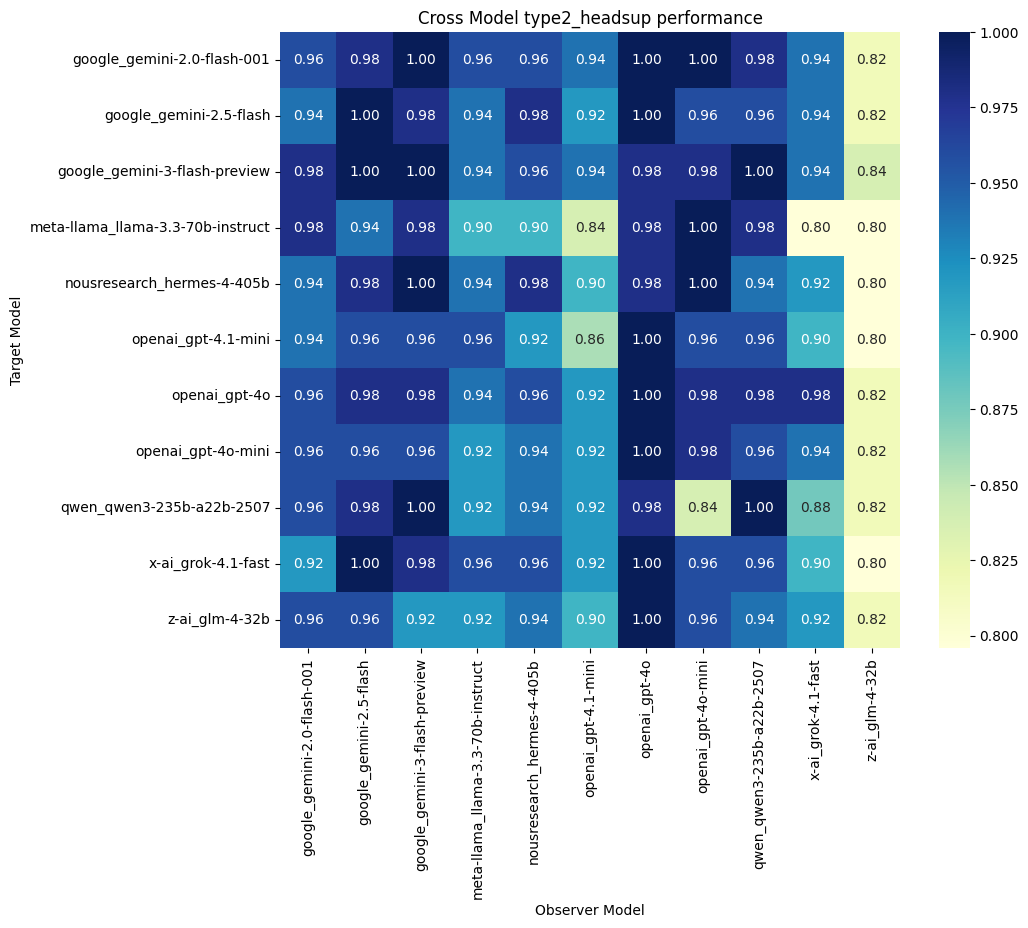

In [3]:
# Visualise results as heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metric = "type2_headsup"
transformed = df.copy()
transformed["Observer"] = transformed.apply(lambda x: x["Target"] if x["Observer"] == "self_introspection" else x["Observer"], axis=1)
# Convert from .2f percentage to float 
transformed[metric] = transformed[metric].str.rstrip('%').astype('float') / 100.0

pivot_table = transformed.pivot(columns="Observer", index="Target", values=metric)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Cross Model {metric} performance")
plt.xlabel("Observer Model")
plt.ylabel("Target Model")
plt.show()

## double centred version

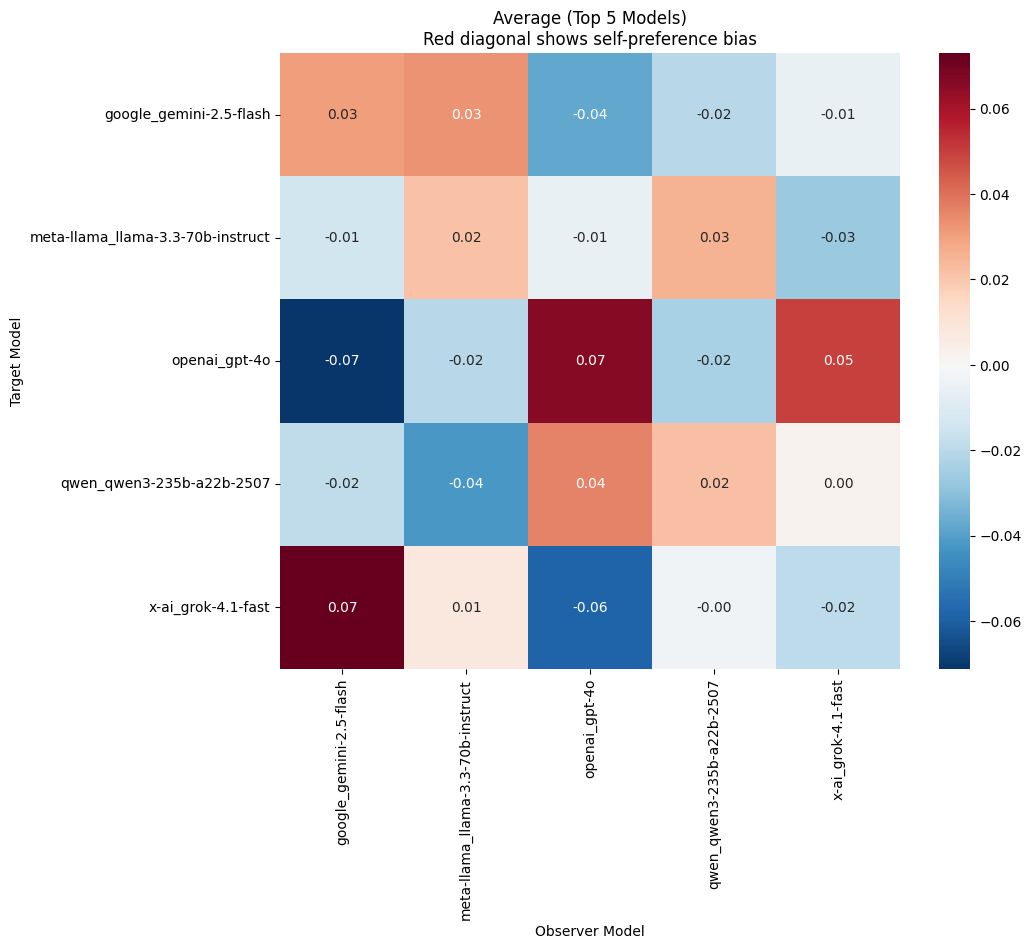

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def visualize_cross_model_heatmap(dataframe, metric, top_n_models=5):
    transformed = dataframe.copy()

    # 1. Clean data and handle 'self_introspection'
    transformed["Observer"] = transformed.apply(
        lambda x: x["Target"] if x["Observer"] == "self_introspection" else x["Observer"], 
        axis=1
    )

    # 2. Convert percentage strings to floats
    if transformed[metric].dtype == object:
        transformed[metric] = transformed[metric].str.rstrip('%').astype('float') / 100.0


    # 3. FILTER: Keep only the top N best-performing models based on average score
    top_models = set(
        transformed.groupby("Observer")[metric]
        .mean()
        .sort_values(ascending=False)
        .head(top_n_models)
        .index
    )

    transformed = transformed[transformed["Target"].isin(top_models) & transformed["Observer"].isin(top_models)]

    # 4. Create pivot table
    pivot_table = transformed.pivot(columns="Observer", index="Target", values=metric)

    pivot_table
    # 5. Apply Log Transformation
    log_pivot = np.log(pivot_table + 1e-5)

    # 6. Apply Double Centering
    row_means = log_pivot.mean(axis=1)
    col_means = log_pivot.mean(axis=0)
    global_mean = log_pivot.values.mean()

    centered_pivot = log_pivot.sub(row_means, axis=0).sub(col_means, axis=1).add(global_mean)

    # 7. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(centered_pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0)

    plt.title(f"{metric} (Top {top_n_models} Models)\nRed diagonal shows self-preference bias")
    plt.xlabel("Observer Model")
    plt.ylabel("Target Model")
    plt.show()

metric = "Average"
visualize_cross_model_heatmap(df, metric, top_n_models=5)

ValueError: Unknown format code 'd' for object of type 'float'

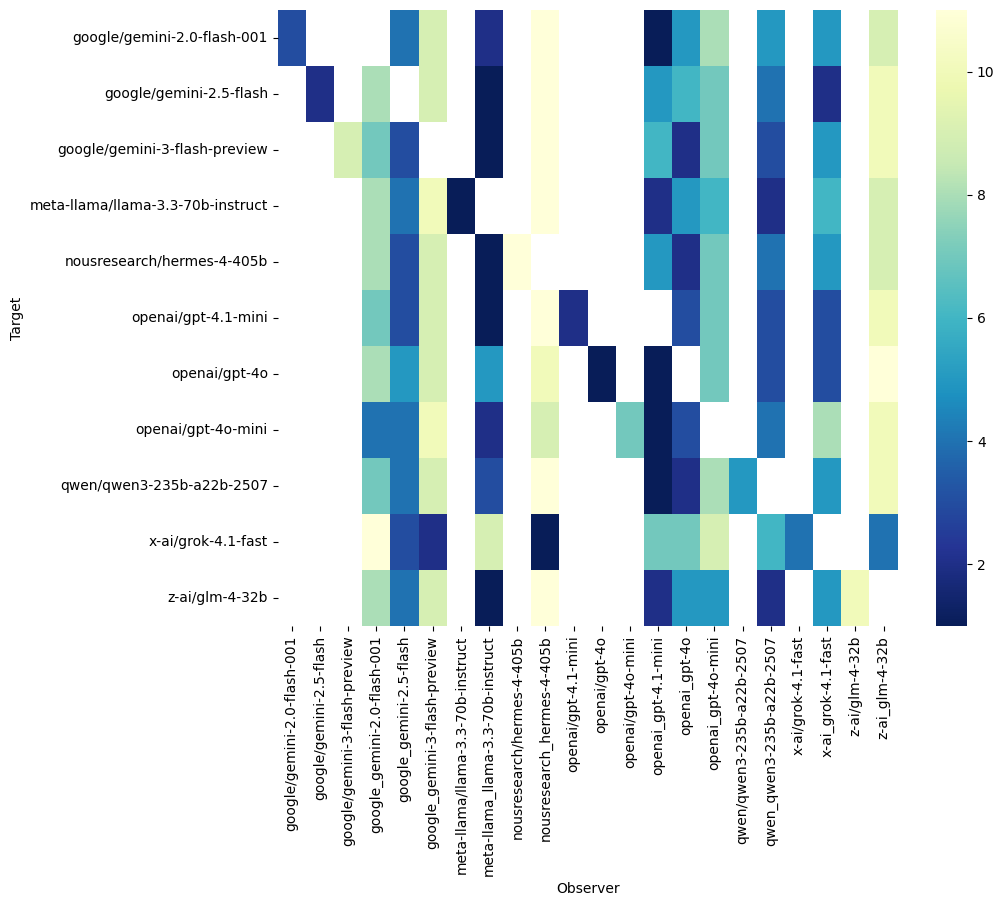

In [50]:
# Rank observers for each target (new column)
ranked = transformed.copy()
ranked['Rank'] = ranked.groupby('Target')[metric].rank(ascending=False, method='min').astype(int)
ranked.sort_values(by=['Target', 'Rank'], inplace=True)

# # visualise as heatmap
pivot_rank = ranked.pivot(index="Target", columns="Observer", values="Rank")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_rank, annot=True, fmt="d", cmap="YlGnBu_r")
plt.title(f"Cross Model {metric} Rank performance")
plt.xlabel("Observer Model")
plt.ylabel("Target Model")
plt.show()


In [10]:
import numpy as np
from scipy import stats

# Assuming 'matrix' is your 11x11 Success Performance data
diagonal = np.diag(pivot_table)

# Mask the diagonal to calculate peer averages
mask = np.eye(pivot_table.shape[0], dtype=bool)
peer_averages = np.array([pivot_table.values[i, ~mask[i]].mean() for i in range(len(pivot_table))])
# Perform the Wilcoxon Signed-Rank Test
statistic, p_value = stats.wilcoxon(diagonal, peer_averages, alternative='greater')

print(f"Wilcoxon Statistic: {statistic}, p-value: {p_value}")

Wilcoxon Statistic: 10.0, p-value: 0.0625
